# DeepSeek Coder 6.7b Instruct - HumanEval Benchmark Pipeline with Contextual Bandit

This notebook implements a pipeline to benchmark the `deepseek-ai/deepseek-coder-6.7b-instruct` model on the HumanEval dataset using various prompting strategies.
We use contextual bandit to adaptively select from: zero_shot, few_shot, cot, hint.
 **Bandit-Optimized** (adaptive from all strategies)

Finally, we calculate the Pass@1 score using a custom serial evaluator (Windows-compatible) and compare.

In [1]:
import torch
import numpy as np
import ast  # For compile check
from transformers import AutoTokenizer, AutoModelForCausalLM
from human_eval.data import write_jsonl, read_problems
from tqdm import tqdm
import json
import os
import sys
import gc

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Model Loading
We load the model with 4-bit quantization to save memory. If you have enough VRAM (24GB+), you can remove `load_in_4bit=True`.

In [2]:
model_name = "deepseek-ai/deepseek-coder-6.7b-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model.eval()
print("Model loaded successfully!")

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Loading checkpoint shards: 100%|██████████| 2/2 [00:12<00:00,  6.29s/it]


Model loaded successfully!


## 2. Prompting Strategies (for Baseline and Bandit Arms)
Define functions to construct prompts. For bandit, arms correspond to strategies: 0=zero_shot, 1=few_shot, 2=cot, 3=hint.

In [3]:
def get_prompt(arm_id, problem):
    prompt_content = ""
    
    if arm_id == 0:  # zero_shot
        prompt_content = f"You are an expert Python programmer. Complete the following function by writing only the code inside the body. Do not repeat the signature or add explanations.\n\n{problem['prompt']}"
    
    elif arm_id == 1:  # few_shot
        example = """
Example 1:
def add(a, b):
'''Returns the sum of a and b'''
return a + b
Example 2:
def reverse_string(s):
'''Reverses the input string'''
return s[::-1]
Example 3:
def find_max(lst):
'''Finds the maximum value in a list'''
return max(lst)
"""
        prompt_content = f"You are an expert Python programmer. Here are some examples of completed functions:\n{example}\n\nNow complete this function by writing only the code inside the body:\n{problem['prompt']}"
    
    elif arm_id == 2:  # cot
        prompt_content = f"You are an expert Python programmer. Think step-by-step about the problem, explain your reasoning briefly, then write the final code inside the function body only. End with the code.\n\nProblem:\n{problem['prompt']}"
    
    elif arm_id == 3:  # hint
        hint = "Hint: Handle edge cases like empty inputs, negative numbers, and large values. Use efficient data structures if needed."
        prompt_content = f"You are an expert Python programmer. {hint}\nComplete the function by writing only the code inside the body:\n{problem['prompt']}"
    
    # Format for DeepSeek Instruct
    messages = [
        { 'role': 'user', 'content': prompt_content }
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

## 3. Generation Pipeline (Modified for Bandit)
Iterate through HumanEval problems and generate solutions. For baseline, use fixed arm=0 (zero_shot). For bandit, select dynamically from all arms.

In [4]:
def generate_solutions(problems, bandit=None, fixed_arm=None, num_samples=1):
    torch.cuda.empty_cache()
    gc.collect()
    
    samples = []
    print("Starting generation...")
    
    for task_id, problem in tqdm(problems.items(), desc="Generating", leave=False):
        if bandit:
            context = np.array(extract_features(problem))  # ← PASTI np.array
            arm = bandit.select_arm(context)               # ← ini yang naikkan t
        else:
            arm = fixed_arm
        
        prompt = get_prompt(arm, problem)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4096).to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,  # Greedy lebih stabil
                pad_token_id=tokenizer.eos_token_id,
            )
        
        generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True).strip()
        
        if "```python" in generated:
            code = generated.split("```python", 1)[1].split("```", 1)[0].strip()
        elif "```" in generated:
            code = generated.split("```", 1)[1].split("```", 1)[0].strip()
        else:
            code = generated

        sample = {
            "task_id": task_id,
            "completion": code,
            "arm": arm,
            "context": context.tolist() if bandit else None
        }
        samples.append(sample)
    
    return samples

## 4. Custom Evaluation (Windows Compatible) with Reward Calculation
Custom serial evaluator with timeout. Added compile check and reward calc for bandit.

In [12]:
# 4. Custom Evaluation (Windows Compatible + Live Progress + TIMEOUT + STRATEGY LOGGING)
from tqdm import tqdm
import threading
import ast

# Mapping arm_id → nama strategi (sama seperti yang Anda pakai di get_prompt)
STRATEGY_NAMES = {
    0: "zero_shot",
    1: "few_shot",
    2: "cot",
    3: "hint"
}

def run_with_timeout(code, timeout_seconds=10):
    result = {'success': False, 'error': None}
    def target():
        try:
            exec_globals = {}
            exec(code, exec_globals)
            result['success'] = True
        except Exception as e:
            result['error'] = e
    thread = threading.Thread(target=target)
    thread.daemon = True
    thread.start()
    thread.join(timeout_seconds)
    if thread.is_alive():
        return False, 'TIMEOUT'
    return result['success'], result.get('error')

def check_compile(code):
    try:
        ast.parse(code)
        return 1
    except SyntaxError:
        return 0

def evaluate_functional_correctness_custom(samples, problems, timeout=10, bandit=None):
    passed = 0
    total = len(samples)
    cumulative_reward = 0.0
    
    print(f"Evaluating {total} samples (timeout: {timeout}s per test)...\n")
    pbar = tqdm(samples, desc="Evaluating", leave=True)
    
    for i, sample in enumerate(pbar):
        task_id = sample['task_id']
        completion = sample['completion']
        problem = problems[task_id]
        
        full_code = (
            problem['prompt'] + 
            completion + 
            "\n" + 
            problem['test'] + 
            f"\ncheck({problem['entry_point']})"
        )
        
        compile_success = check_compile(full_code)
        pass_success, error = run_with_timeout(full_code, timeout)
        reward = 0.3 * compile_success + 0.7 * (1 if pass_success else 0)
        cumulative_reward += reward
        
        # === TAMBAHAN: Simpan hasil evaluasi ke sample ===
        sample['passed'] = pass_success                     # True / False
        sample['compile_ok'] = bool(compile_success)        # untuk debugging
        sample['reward'] = reward
        
        # === TAMBAHAN: Tentukan nama strategi yang digunakan ===
        if 'arm' in sample:
            arm_id = sample['arm']
            sample['strategy'] = STRATEGY_NAMES.get(arm_id, f"unknown_arm_{arm_id}")
        else:
            sample['strategy'] = "no_arm"   # kalau generate tanpa bandit
        if bandit and 'arm' in sample and 'context' in sample:
            try:
                ctx_array = np.array(sample['context'], dtype=float).reshape(-1, 1)
                bandit.update(sample['arm'], ctx_array, reward)
            except Exception as e:
                print(f"UPDATE GAGAL untuk task {sample['task_id']}: {e}")
                print(f"  context type: {type(sample['context'])}, content: {sample['context'][:5]}...")
        
        
        # Logging
        status = "PASS" if pass_success else ("TIMEOUT" if error == 'TIMEOUT' else "FAIL")
        strategy_name = sample['strategy']
        pbar.write(f"  [{i+1:3d}/{total}] {task_id} → {status:7} | Strategy: {strategy_name}")
        
        if pass_success:
            passed += 1
            
        current_score = (passed / (i + 1)) * 100
        pbar.set_postfix({
            "Live Pass@1": f"{current_score:5.1f}%",
            "Passed": f"{passed}/{i+1}",
            "Avg Reward": f"{cumulative_reward / (i + 1):.4f}"
        })
    
    final_score = (passed / total) * 100 if total > 0 else 0.0
    avg_reward = cumulative_reward / total
    print(f"\nEVALUASI SELESAI → Pass@1: {final_score:5.1f}%  ({passed}/{total}) | Avg Reward: {avg_reward:.4f}\n")
    
    return {"pass@1": final_score, "avg_reward": avg_reward}

## 5. Context Extraction for Bandit
Extract simple features from problem as context vector.

In [20]:
def extract_features(problem):
    prompt = problem['prompt']
    docstring = prompt.split('"""')[1].lower() if '"""' in prompt else prompt.lower()
    
    input_ids = tokenizer(prompt, return_tensors='pt')['input_ids'][0]
    token_len = len(input_ids)
    
    words = docstring.split()
    doc_len = len(words)
    
    # FITUR KONTINU (ini yang bikin LinUCB hidup!)
    features = [
        token_len / 1000.0,           # 0
        doc_len / 200.0,              # 1  ← panjang docstring
        len(set(words)) / 100.0,      # 2  ← vocabulary richness
        docstring.count('\n') / 10.0, # 3  ← jumlah baris
        'return' in docstring,        # 4
        'for ' in docstring or 'while ' in docstring,  # 5 loop
        'if ' in docstring,           # 6
        'def ' in docstring,          # 7 helper function?
        'list' in docstring or 'array' in docstring,
        'string' in docstring or 'text' in docstring,
        'sort' in docstring or 'sorted' in docstring,
        'graph' in docstring or 'node' in docstring or 'edge' in docstring,
        'tree' in docstring or 'root' in docstring,
        'dp' in docstring or 'memo' in docstring or 'cache' in docstring,
        'recursion' in docstring or 'recursive' in docstring,
        'bit' in docstring or '&' in docstring or '|' in docstring or '<<' in docstring,
        'greedy' in docstring,
        'math' in docstring or 'formula' in docstring,
        'geometry' in docstring or 'point' in docstring or 'distance' in docstring,
    ]
    
    return [float(x) for x in features]  # ← PASTI float semua!

## 6. Contextual Bandit Implementation (LinUCB)
Simple LinUCB for contextual bandit.

In [21]:
class BestLinUCB:
    def __init__(self, num_arms=4, dim_context=19, alpha=3.0, force_explore=50):
        self.num_arms = num_arms
        self.dim_context = dim_context
        self.alpha_base = alpha
        self.force_explore = force_explore
        self.t = 0
        
        self.A = [np.eye(dim_context) for _ in range(num_arms)]
        self.b = [np.zeros((dim_context, 1)) for _ in range(num_arms)]
        self.theta = [np.zeros((dim_context, 1)) for _ in range(num_arms)]
    
    def select_arm(self, context):
        self.t += 1
        if self.t <= self.force_explore:
            arm = random.randint(0, self.num_arms - 1)
            print(f"[FORCE EXPLORE] t={self.t:3d} → random arm {arm}")
            return arm
        alpha = self.alpha_base * np.sqrt(np.log(self.t + 1))
        context = context.reshape(-1, 1)
        ucb = []
        
        for a in range(self.num_arms):
            A_inv = np.linalg.inv(self.A[a])
            theta = self.theta[a]
            mean = theta.T @ context
            uncertainty = alpha * np.sqrt(context.T @ A_inv @ context)
            ucb.append(float(mean + uncertainty))
        
        chosen = int(np.argmax(ucb))
        print(f"[LinUCB] t={self.t} → arm {chosen} (α={alpha:.2f})")
        return chosen
    
    def update(self, arm, context, reward):
        context = context.reshape(-1, 1)
        self.A[arm] += context @ context.T
        self.b[arm] += reward * context
        self.theta[arm] = np.linalg.inv(self.A[arm]) @ self.b[arm]

## 7. Execution & Benchmark (Baseline vs Bandit)
Run baseline (fixed zero-shot) then bandit-optimized (from all strategies).

In [22]:
import os
import urllib.request
import torch
import gc
import random

HUMAN_EVAL_URL = "https://github.com/openai/human-eval/raw/master/data/HumanEval.jsonl.gz"
LOCAL_EVAL_FILE = "HumanEval.jsonl.gz"

if not os.path.exists(LOCAL_EVAL_FILE):
    print("Downloading HumanEval dataset...")
    urllib.request.urlretrieve(HUMAN_EVAL_URL, LOCAL_EVAL_FILE)
    print("Downloaded.")
results_summary = {}
problems = read_problems(LOCAL_EVAL_FILE)
problems = dict(list(problems.items()))  
problem_items = list(problems.items())
random.seed(42)                  
random.shuffle(problem_items)
problems = dict(problem_items)
NUM_ARMS = 4
DIM_CONTEXT = 19
bandit = BestLinUCB(num_arms=4, dim_context=19, alpha=3.0, force_explore=50)

print("Bandit siap! Akan eksplorasi")
torch.cuda.empty_cache()
gc.collect()
samples_bandit = generate_solutions(problems, bandit=bandit)
print("Evaluating bandit...")
results_bandit = evaluate_functional_correctness_custom(
    samples_bandit, problems, timeout=10, bandit=bandit
)

results_summary['bandit'] = results_bandit
print(f"Bandit Results: {results_bandit}")
print("-"*50)

# FINAL COMPARISON
print("FINAL COMPARISON:")
bandit_pass = results_bandit['pass@1']
baseline_pass = results_summary.get('baseline', {'pass@1': 0})['pass@1']
print(f"Bandit All Strategies → Pass@1: {bandit_pass:5.1f}%")

Bandit siap! Akan eksplorasi
Starting generation...


Generating:   0%|          | 0/164 [00:00<?, ?it/s]

[FORCE EXPLORE] t=  1 → random arm 1


Generating:   1%|          | 1/164 [00:04<13:20,  4.91s/it]

[FORCE EXPLORE] t=  2 → random arm 0


...

  [ 44/164] HumanEval/99 → FAIL    | Strategy: zero_shot
  [ 45/164] HumanEval/49 → PASS    | Strategy: zero_shot
21
45123
54321
12345
  [ 46/164] HumanEval/65 → PASS    | Strategy: few_shot
  [ 47/164] HumanEval/118 → PASS    | Strategy: zero_shot
  [ 48/164] HumanEval/115 → FAIL    | Strategy: zero_shot
  [ 49/164] HumanEval/64 → FAIL    | Strategy: cot
  [ 50/164] HumanEval/16 → PASS    | Strategy: zero_shot
  [ 51/164] HumanEval/83 → FAIL    | Strategy: zero_shot
  [ 52/164] HumanEval/69 → PASS    | Strategy: zero_shot
  [ 53/164] HumanEval/131 → FAIL    | Strategy: zero_shot
[2, 2, 2]
[5, 5]
[2, 5, 7]
  [ 54/164] HumanEval/25 → PASS    | Strategy: zero_shot
  [ 55/164] HumanEval/78 → PASS    | Strategy: zero_shot
  [ 56/164] HumanEval/110 → PASS    | Strategy: zero_shot
  [ 57/164] HumanEval/13 → PASS    | Strategy: zero_shot
  [ 58/164] HumanEval/91 → FAIL    | Strategy: zero_shot
  [ 59/164] HumanEval/134 → FAIL    | Strategy: zero_shot
  [ 60/164] HumanEval/140 → FAIL    | Stra

Evaluating:  84%|████████▍ | 138/164 [00:00<00:00, 277.31it/s, Live Pass@1=65.0%, Passed=93/143, Avg Reward=0.7490]

  [ 91/164] HumanEval/141 → FAIL    | Strategy: zero_shot
  [ 92/164] HumanEval/81 → FAIL    | Strategy: zero_shot
  [ 93/164] HumanEval/117 → PASS    | Strategy: zero_shot
  [ 94/164] HumanEval/157 → PASS    | Strategy: zero_shot
  [ 95/164] HumanEval/142 → FAIL    | Strategy: zero_shot
  [ 96/164] HumanEval/126 → FAIL    | Strategy: zero_shot
  [ 97/164] HumanEval/100 → PASS    | Strategy: zero_shot
  [ 98/164] HumanEval/113 → PASS    | Strategy: zero_shot
  [ 99/164] HumanEval/111 → PASS    | Strategy: zero_shot
  [100/164] HumanEval/98 → PASS    | Strategy: zero_shot
  [101/164] HumanEval/29 → FAIL    | Strategy: zero_shot
  [102/164] HumanEval/84 → FAIL    | Strategy: zero_shot
  [103/164] HumanEval/119 → FAIL    | Strategy: zero_shot
  [104/164] HumanEval/153 → PASS    | Strategy: zero_shot
  [105/164] HumanEval/90 → FAIL    | Strategy: zero_shot
  [106/164] HumanEval/24 → PASS    | Strategy: zero_shot
  [107/164] HumanEval/73 → PASS    | Strategy: zero_shot
  [108/164] HumanEval

Evaluating: 100%|██████████| 164/164 [00:00<00:00, 263.15it/s, Live Pass@1=63.4%, Passed=104/164, Avg Reward=0.7384]

  [145/164] HumanEval/143 → PASS    | Strategy: zero_shot
  [146/164] HumanEval/161 → PASS    | Strategy: zero_shot
[1, 2, 3]
[5]
  [147/164] HumanEval/129 → FAIL    | Strategy: zero_shot
29
2
  [148/164] HumanEval/59 → PASS    | Strategy: zero_shot
  [149/164] HumanEval/55 → PASS    | Strategy: zero_shot
  [150/164] HumanEval/23 → PASS    | Strategy: zero_shot
  [151/164] HumanEval/7 → FAIL    | Strategy: zero_shot
  [152/164] HumanEval/8 → FAIL    | Strategy: zero_shot
  [153/164] HumanEval/108 → FAIL    | Strategy: zero_shot
  [154/164] HumanEval/151 → PASS    | Strategy: zero_shot
  [155/164] HumanEval/22 → FAIL    | Strategy: zero_shot
  [156/164] HumanEval/139 → PASS    | Strategy: zero_shot
  [157/164] HumanEval/26 → FAIL    | Strategy: zero_shot
  [158/164] HumanEval/35 → FAIL    | Strategy: zero_shot
  [159/164] HumanEval/57 → PASS    | Strategy: zero_shot
[2, 3, 4, 5]
[2, 3]
  [160/164] HumanEval/62 → FAIL    | Strategy: zero_shot
  [161/164] HumanEval/70 → PASS    | Strategy

## 8. Final Results Comparison

           pass@1  avg_reward
bandit  63.414634    0.738415


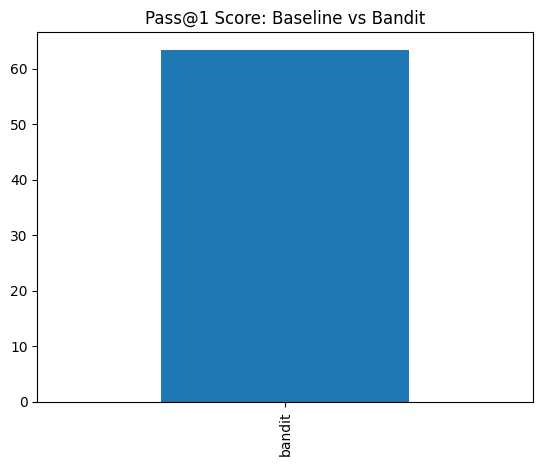

In [23]:
import pandas as pd

df = pd.DataFrame(results_summary).T
print(df)

# Optional: Plotting
try:
    df['pass@1'].plot(kind='bar', title='Pass@1 Score: Baseline vs Bandit')
except ImportError:
    pass

In [24]:
# === ANALISIS STRATEGI YANG DIPILIH BANDIT ===
print("="*70)
print("ANALISIS PEMILIHAN STRATEGI OLEH CONTEXTUAL BANDIT")
print("="*70)

from collections import Counter

strategies_used = [s['strategy'] for s in samples_bandit if 'strategy' in s]
counts = Counter(strategies_used)
total = len(strategies_used)

print(f"\nDistribusi Pemilihan Strategi (total {total} soal):")
print("-" * 55)
for strategy, cnt in counts.most_common():
    perc = cnt / total * 100
    passed_cnt = sum(1 for s in samples_bandit if s.get('strategy') == strategy and s.get('passed'))
    pass_rate = passed_cnt / cnt * 100 if cnt > 0 else 0
    print(f"{strategy:10} → {cnt:3d} kali ({perc:5.1f}%) → Pass@1: {pass_rate:5.1f}%")

# Strategi terbaik
if counts:
    best = max(counts.keys(), key=lambda x: sum(1 for s in samples_bandit if s.get('strategy')==x and s.get('passed',False)) / counts[x])
    best_rate = sum(1 for s in samples_bandit if s.get('strategy')==best and s.get('passed',False)) / counts[best] * 100
    print(f"\nStrategi TERBAIK yang dipelajari bandit → {best} ({best_rate:.1f}%)")
    print(f"Overall Pass@1 bandit                  → {results_bandit['pass@1']:.1f}%")
    print(f"Potensi maksimal (oracle)              → {best_rate:.1f}%")
print("="*70)

ANALISIS PEMILIHAN STRATEGI OLEH CONTEXTUAL BANDIT

Distribusi Pemilihan Strategi (total 164 soal):
-------------------------------------------------------
zero_shot  → 131 kali ( 79.9%) → Pass@1:  62.6%
few_shot   →  16 kali (  9.8%) → Pass@1:  62.5%
cot        →  10 kali (  6.1%) → Pass@1:  60.0%
hint       →   7 kali (  4.3%) → Pass@1:  85.7%

Strategi TERBAIK yang dipelajari bandit → hint (85.7%)
Overall Pass@1 bandit                  → 63.4%
Potensi maksimal (oracle)              → 85.7%
